## 1. Creating Depth Map 

In [1]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# cam0=[1758.23 0 947.17; 0 1758.23 552.44; 0 0 1]
# cam1=[1758.23 0 947.17; 0 1758.23 552.44; 0 0 1]
# doffs=0
# baseline=78.28
# width=1920
# height=1080
# ndisp=170
# vmin=50
# vmax=144

# Q matrix - Camera parameters - Can also be found using stereoRectify
Q = np.array(([1.0, 0.0, 0.0, -947.17],
              [0.0, 1.0, 0.0, -552.44],
              [0.0, 0.0, 0.0, 1758.23],
              [0.0, 0.0, 1.0/78.28, 0.0]),dtype=np.float32)

In [2]:
#model_type = "DPT_Large"     # MiDaS v3 - Large     (highest accuracy, slowest inference speed)
model_type = "DPT_Hybrid"   # MiDaS v3 - Hybrid    (medium accuracy, medium inference speed)
#model_type = "MiDaS_small"  # MiDaS v2.1 - Small   (lowest accuracy, highest inference speed)

midas = torch.hub.load("intel-isl/MiDaS", model_type)

Using cache found in C:\Users\vikas/.cache\torch\hub\intel-isl_MiDaS_master
C:\Users\vikas\AppData\Local\Programs\Python\Python310\lib\site-packages\timm\models\_factory.py:114: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(


In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
midas.to(device)
midas.eval()

DPTDepthModel(
  (pretrained): Module(
    (model): VisionTransformer(
      (patch_embed): HybridEmbed(
        (backbone): ResNetV2(
          (stem): Sequential(
            (conv): StdConv2dSame(3, 64, kernel_size=(7, 7), stride=(2, 2), bias=False)
            (norm): GroupNormAct(
              32, 64, eps=1e-05, affine=True
              (drop): Identity()
              (act): ReLU(inplace=True)
            )
            (pool): MaxPool2dSame(kernel_size=(3, 3), stride=(2, 2), padding=(0, 0), dilation=(1, 1), ceil_mode=False)
          )
          (stages): Sequential(
            (0): ResNetStage(
              (blocks): Sequential(
                (0): Bottleneck(
                  (downsample): DownsampleConv(
                    (conv): StdConv2dSame(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
                    (norm): GroupNormAct(
                      32, 256, eps=1e-05, affine=True
                      (drop): Identity()
                      (act): Identit

In [4]:
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if model_type == "DPT_Large" or model_type == "DPT_Hybrid":
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

Using cache found in C:\Users\vikas/.cache\torch\hub\intel-isl_MiDaS_master


In [28]:
img = cv2.imread('Images/Clouds/chair.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_batch = transform(img).to(device)

In [29]:
with torch.no_grad():
    prediction = midas(input_batch)

    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

output = prediction.cpu().numpy()

# Normalization of output
depth_map = cv2.normalize(output, None, 0, 1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)

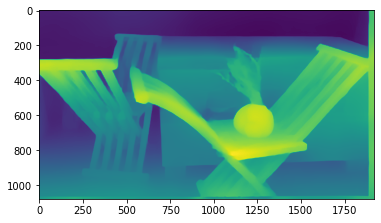

In [30]:
plt.imshow(depth_map)
# plt.show()

## 2. Reproject points on 3D

In [31]:
points_3D = cv2.reprojectImageTo3D(depth_map, Q, handleMissingValues=False)

# Get rid of points with value 0 (i.e no depth)
mask_map = depth_map > 0.4

#Mask colors and points. 
output_points = points_3D[mask_map]
output_colors = img[mask_map]

## 3. Visualization

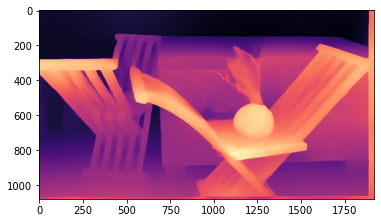

In [32]:
depth_map = (depth_map*255).astype(np.uint8)
depth_map = cv2.applyColorMap(depth_map , cv2.COLORMAP_MAGMA)

plt.imshow(cv2.cvtColor(depth_map, cv2.COLOR_BGR2RGB))
plt.show()

## 4.Creating Point Clouds 

In [33]:
#Function to create point cloud file
def create_output(vertices, colors, filename):
    colors = colors.reshape(-1,3)
    vertices = np.hstack([vertices.reshape(-1,3),colors])

    ply_header = '''ply
        format ascii 1.0
        element vertex %(vert_num)d
        property float x
        property float y
        property float z
        property uchar red
        property uchar green
        property uchar blue
        end_header
        '''
    with open(filename, 'w') as f:
        f.write(ply_header %dict(vert_num=len(vertices)))
        np.savetxt(f,vertices,'%f %f %f %d %d %d')

In [34]:
output_file = 'PointClouds/pointCloudDeepLearning.ply'
#Generate point cloud 
create_output(output_points, output_colors, output_file)

## 5. Plotting Results

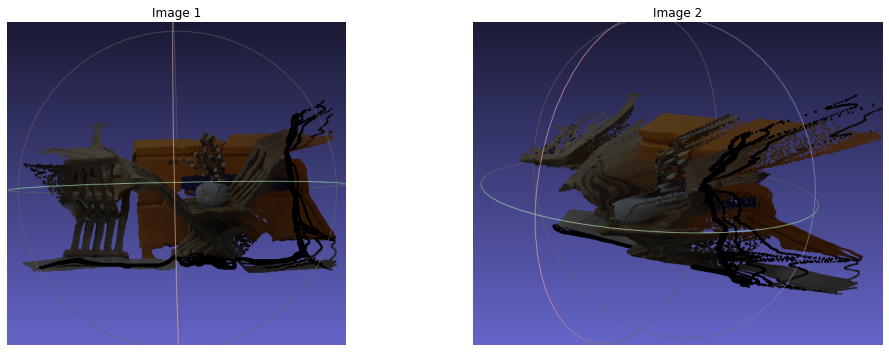

In [39]:
front = cv2.imread('Images/Clouds/Front-View.png')
side = cv2.imread('Images/Clouds/Side-View.png')

front = cv2.cvtColor(front, cv2.COLOR_BGR2RGB)
side = cv2.cvtColor(side, cv2.COLOR_BGR2RGB)

images = [front, side]

fig, axs = plt.subplots(1, 2,figsize=(15, 5))

for i, image in enumerate(images):
    axs[i].imshow(image)
    axs[i].set_title(f'Image {i+1}')
    axs[i].axis('off')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

## More on Q-Matrix

### Q = [1 0 0 -cx;     0 1 0 -cy;     0 0 0   f;     0 0 -1/Tx  0]

- cx, cy are the principal point coordinates.
- f is the focal length in pixels (assumed to be the same for both cameras in a stereo setup).
- Tx is the baseline (distance between the cameras).
- Tx  =  -baseline